## BERT Tiny MPS

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%reload_ext autoreload

import pandas as pd
import os
from pathlib import Path
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
%%time

current_working_folder = Path.cwd()
current_folder_abs = os.path.abspath(current_working_folder)
file_name = 'mental_health_data.csv'
data_file_path = os.path.join(current_folder_abs, file_name)

CPU times: user 139 μs, sys: 153 μs, total: 292 μs
Wall time: 254 μs


## BERT Tiny Modified Final accuracy
- changed oversampling to be done after train, test split not before
- to prevent data leakage

Loading cached training data...
Loading cached validation data...
After TensorDataset


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                          | Params | Mode 
------------------------------------------------------------------
0 | model   | BertForSequenceClassification | 4.4 M  | eval 
1 | loss_fn | CrossEntropyLoss              | 0      | train
------------------------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.553    Total estimated model params size (MB)
1         Modules in train mode
51        Modules in eval mode


After DataLoader
Before Training


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Training Accuracy: 0.8977

 Running final evaluation on validation set...

 Classification Report:
                   precision    recall  f1-score   support

  COVID19_support       1.00      1.00      1.00    126897
      EDAnonymous       0.99      1.00      0.99    126897
        addiction       0.99      1.00      1.00    126898
             adhd       0.96      0.99      0.97    126898
       alcoholism       0.99      1.00      1.00    126898
          anxiety       0.92      0.96      0.94    126898
           autism       0.99      1.00      1.00    126898
    bipolarreddit       0.99      1.00      1.00    126898
              bpd       0.98      1.00      0.99    126897
       depression       0.85      0.62      0.71    126898
    healthanxiety       0.99      1.00      1.00    126898
           lonely       0.97      1.00      0.98    126898
     mentalhealth       0.88      0.97      0.92    126898
non_mental_health       0.98      0.78      0.87    126898
             pt

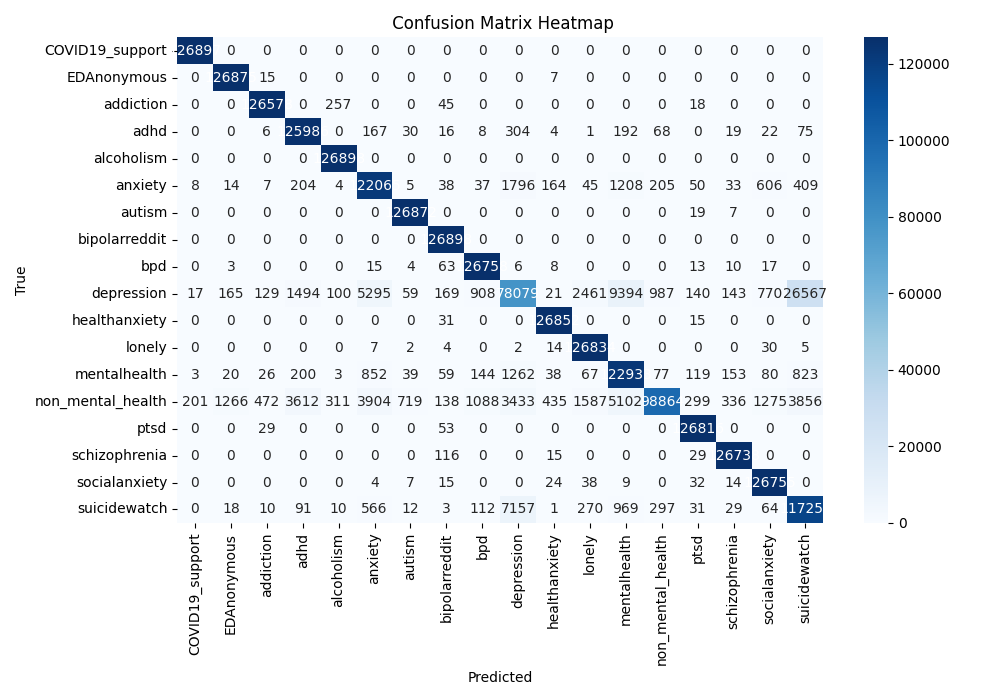

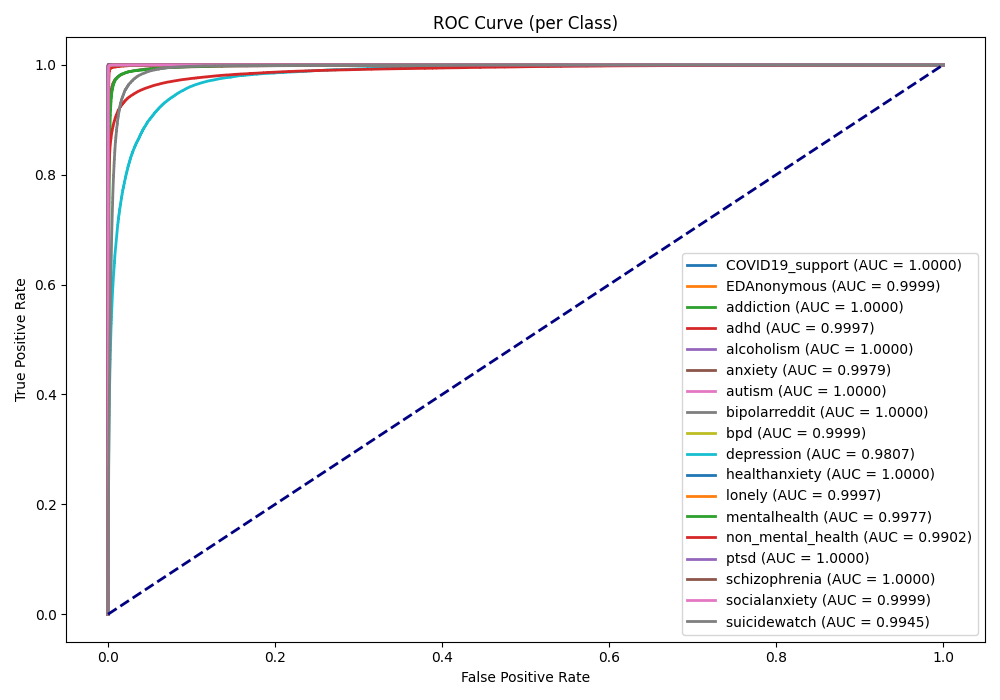

Tokenizer and label encoder saved.
CPU times: user 8h 14min 35s, sys: 1h 58min 4s, total: 10h 12min 40s
Wall time: 9h 55min 21s


In [3]:
%%time
from mentalhealth.bert_tiny_modified import train_pipeline, export_onnx, onnx_predict

mental_health_df = pd.read_csv(data_file_path)
text_data = mental_health_df['cleaned_post'].values
labels = mental_health_df['target'].values

model_name = "prajjwal1/bert-tiny"
max_len = 128
batch_size = 64
epochs = 5

train_npz_path = "cache/train_tiny.npz"
val_npz_path = "cache/val_tiny.npz"

model, tokenizer, label_encoder = train_pipeline(
    text_data, labels,
    model_name=model_name,
    max_len=max_len,
    batch_size=batch_size,
    epochs=epochs,
    train_npz_path=train_npz_path,
    val_npz_path=val_npz_path,
    use_profiler=False
)

In [4]:
new_texts = [
    "Biden announces new environmental policies.",
    "OpenAI introduces GPT-5 language model.",
    "Just got back from treatment 90 days at an all boy adolescent rehab, todays my first day back home and goddamn. Didn’t expect how overwhelming it would be. So much to do, so much temptation already. Friends saying I’m a new person, parents saying I’m a new person. New sc and number so I got nobody on my social, starting up gonna be difficult as fuck but so worth it. "
]

# Export to ONNX
export_onnx(model, tokenizer, save_path="onnx/bert_tiny_model_optimized.onnx", max_len=128)

predictions = onnx_predict(new_texts, tokenizer, label_encoder, onnx_path="onnx/bert_tiny_model_optimized.onnx", max_len=128)
print(predictions)

Exporting to ONNX...
Model saved to onnx/bert_tiny_model_optimized.onnx
ONNX prediction...
['non_mental_health' 'non_mental_health' 'addiction']


## SHAP for BERT

In [5]:
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [6]:
mental_health_df = pd.read_csv(data_file_path)
text_data = mental_health_df['cleaned_post'].values
labels = mental_health_df['target'].values

In [7]:
text_data[0], labels[0]

("Bersa Thunder 22: Long-term reliability? Hi, folks.  The Bersa Thunder 22 has caught my eye.  The reviews I've read seem to agree that it's a good pistol for the price, especially with quality ammo.  But pretty much all the reviews are from people who just got it.  Since it is a lower-end gun, I'm a bit concerned about the long-term reliability of it.\n\nHad anyone had a Bersa Thunder 22 for a few years?  How's it holding up?\n\nThanks!",
 'non_mental_health')

In [8]:

data = list(zip(text_data, labels))
np.random.shuffle(data)
shuffled_text_data, shuffled_labels = zip(*data)

unique_labels = np.unique(shuffled_labels)
random_samples = []

# Collect 5 samples with different labels
for label in unique_labels:
    indices = [i for i, lbl in enumerate(shuffled_labels) if lbl == label]
    if indices:
        random_samples.append((shuffled_text_data[indices[0]], shuffled_labels[indices[0]]))

    if len(random_samples) == 5:
        break

random_samples

[("Sick of conspiracy theories and panic mongering I am so sick of all the conspiracy theories around the virus and all the media posts that just seem to promote panic to get views. I want to see more headlines about the recoveries, or the countries and people working together instead.\n\nI live in a country where the lockdown is one of the strictest in the world. Alcohol sales are banned. Cigarettes are banned. Takeaway s are banned. Exercise outside is banned. Police and army are patrolling/set up road blocks and fear of them abusing their power is very real. The economy is taking a major hit and the lockdown has just been extended for another 2 weeks.\n\nAll this is causing me to have anxiety attacks over what is going to happen, not only with the virus, but afterwards and I just wish I could see more positive things in the news or on Facebook (which I can't even avoid as I have to use it for work)...\n\nI can't be the only one feeling this way.",
  'COVID19_support'),
 ('me: my eat

In [9]:
random_text_data = [i[0] for i in random_samples]
random_labels = [i[1] for i in random_samples]
print(f"{random_text_data[0]}\n{random_labels[0]}")

Sick of conspiracy theories and panic mongering I am so sick of all the conspiracy theories around the virus and all the media posts that just seem to promote panic to get views. I want to see more headlines about the recoveries, or the countries and people working together instead.

I live in a country where the lockdown is one of the strictest in the world. Alcohol sales are banned. Cigarettes are banned. Takeaway s are banned. Exercise outside is banned. Police and army are patrolling/set up road blocks and fear of them abusing their power is very real. The economy is taking a major hit and the lockdown has just been extended for another 2 weeks.

All this is causing me to have anxiety attacks over what is going to happen, not only with the virus, but afterwards and I just wish I could see more positive things in the news or on Facebook (which I can't even avoid as I have to use it for work)...

I can't be the only one feeling this way.
COVID19_support
